In [39]:
import pandas as pd
import sklearn as sk
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Contexto
- En este documento se exploran distintas posibilidades de estudio y depuración de un conjunto de datos con aplicación concreta al dataset de venta de vinos, con el proposito de desarrollar un flujo de limpieza y modelado enfocado en la prediccion de la compra de vino medinate sus caracteriticas

In [40]:
## Primer vistazo de los datos
url =r"C:\Users\germa\Desktop\Ejercicios\Machine_learning_Vinos\DatosVino.csv"
data = pd.read_csv(url, sep=',')
data_full = data.copy()
data.head(5)



,ID,Beneficio,Compra,Acidez,AcidoCitrico,Azucar,CloruroSodico,Densidad,pH,Sulfatos,Alcohol,Etiqueta,CalifProductor,Clasificacion,Region,PrecioBotella
0,2,515,1,0.16,-0.81,26.10,-0.425,1.02792,3.38,0.70,144.0,M,2,***,1.0,1.00
1,4,585,1,2.64,-0.88,14.80,0.037,0.99518,3.12,0.48,22.0,M,3,***,3.0,3.38
2,8,0,0,0.29,-0.40,21.50,0.060,0.99572,3.49,1.21,10.3,R,3,?,1.0,3.72
3,11,775,1,-1.22,0.34,1.40,0.040,1.03236,3.20,NaN,11.6,B,2,***,2.0,6.23
4,12,596,1,0.27,1.05,11.25,-0.007,0.99620,4.93,0.26,15.0,R,1,?,2.0,2.44


In [41]:
data_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6365 entries, 0 to 6364
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              6365 non-null   int64  
 1   Beneficio       6365 non-null   int64  
 2   Compra          6365 non-null   int64  
 3   Acidez          6365 non-null   float64
 4   AcidoCitrico    6365 non-null   float64
 5   Azucar          6365 non-null   float64
 6   CloruroSodico   6066 non-null   float64
 7   Densidad        6365 non-null   float64
 8   pH              6170 non-null   float64
 9   Sulfatos        5761 non-null   float64
 10  Alcohol         6365 non-null   float64
 11  Etiqueta        6365 non-null   object 
 12  CalifProductor  6365 non-null   int64  
 13  Clasificacion   6365 non-null   object 
 14  Region          6258 non-null   float64
 15  PrecioBotella   6365 non-null   float64
dtypes: float64(10), int64(4), object(2)
memory usage: 795.8+ KB


In [42]:
data_full.describe()

,ID,Beneficio,Compra,Acidez,AcidoCitrico,Azucar,CloruroSodico,Densidad,pH,Sulfatos,Alcohol,CalifProductor,Region,PrecioBotella
count,6365.000000,6365.000000,6365.000000,6365.000000,6365.000000,6365.000000,6066.000000,6365.000000,6170.000000,5761.000000,6365.000000,6365.000000,6258.000000,6365.000000
mean,8010.702278,452.380204,0.785232,0.331214,0.314350,4718.669780,0.051348,0.994204,3.202207,0.526659,16.250102,2.761508,2.011665,2.610652
std,4654.939139,308.380542,0.410694,0.787534,0.861428,21192.546521,0.322715,0.026417,0.678330,0.948039,25.598217,1.319127,0.818336,1.480274
min,2.000000,0.000000,0.000000,-2.790000,-3.240000,-127.100000,-1.171000,0.888090,0.540000,-3.120000,-4.500000,0.000000,1.000000,1.000000
25%,3980.000000,236.000000,1.000000,0.130000,0.020000,0.900000,-0.032750,0.988245,2.960000,0.280000,9.000000,2.000000,1.000000,1.420000
50%,8065.000000,480.000000,1.000000,0.280000,0.310000,5.000000,0.046000,0.994400,3.190000,0.500000,10.500000,3.000000,2.000000,2.190000
75%,12027.000000,671.000000,1.000000,0.650000,0.580000,22.600000,0.146750,1.000600,3.460000,0.880000,12.800000,3.000000,3.000000,3.440000
max,16128.000000,1568.000000,1.000000,3.680000,3.860000,99999.000000,1.351000,1.099240,6.050000,4.210000,150.000000,12.000000,3.000000,11.440000


Primeras impresiones:
- ¿es necesaria la variable ID?
- Respecto a su descripcion, mirando el valor "min", pensar si algunas variables tienen sentido al tener valores negativos
- algo pasa con algunos valores maximos, eso altera mucho la desviacion estandar.


In [43]:
#Analizamos las variables que son objetos y miramos que hacer con ellas
data_full.nunique()

ID                6365
Beneficio          983
Compra               2
Acidez             659
AcidoCitrico       523
Azucar            1639
CloruroSodico     1406
Densidad          3614
pH                 436
Sulfatos           543
Alcohol            312
Etiqueta            10
CalifProductor      13
Clasificacion        5
Region               3
PrecioBotella      598
dtype: int64

Se observa que no todas las variables tienen asignado el tipo correcto de datos. Identificamos factores como Compra (columna 3), Etiqueta (columna 12), Clasificación (columna 14) y Región (columna 15). 

Con nunique podemos obtener el número de valores distintos por cada variable para evaluar cuáles deberían ser factores.Para tipificar un poco el dataset vamos a convertir a categoricas todas las variables que tengan menos de 10 valores disitintos


In [44]:
# Lista de columnas con menos de 10 valores distintos. Potenciales factores
to_factor = list(data_full.loc[:,data_full.nunique() <= 10]);  
# Podemos cambiar el tipo de todas ellas a factor de una vez
data_full[to_factor] = data_full[to_factor].astype('category')
data_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6365 entries, 0 to 6364
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   ID              6365 non-null   int64   
 1   Beneficio       6365 non-null   int64   
 2   Compra          6365 non-null   category
 3   Acidez          6365 non-null   float64 
 4   AcidoCitrico    6365 non-null   float64 
 5   Azucar          6365 non-null   float64 
 6   CloruroSodico   6066 non-null   float64 
 7   Densidad        6365 non-null   float64 
 8   pH              6170 non-null   float64 
 9   Sulfatos        5761 non-null   float64 
 10  Alcohol         6365 non-null   float64 
 11  Etiqueta        6365 non-null   category
 12  CalifProductor  6365 non-null   int64   
 13  Clasificacion   6365 non-null   category
 14  Region          6258 non-null   category
 15  PrecioBotella   6365 non-null   float64 
dtypes: category(4), float64(9), int64(3)
memory usage: 622.5 KB


Dividimos nuestro dataset. por comodidad se separa entre categoricas y numericas ademas se entiende que la variable beneficio y compra estan directamente corelacionadas por lo que ambas se trataran como variables objetivos y se estraeran del porceso de limpieza que se hara a continuacion

In [45]:
varObjCont = data_full.Beneficio
varObjBin = data_full.Compra
data_full = data_full.drop(['Beneficio','Compra','ID'],axis=1)

data_full.head()
data_full.describe()

,Acidez,AcidoCitrico,Azucar,CloruroSodico,Densidad,pH,Sulfatos,Alcohol,CalifProductor,PrecioBotella
count,6365.000000,6365.000000,6365.000000,6066.000000,6365.000000,6170.000000,5761.000000,6365.000000,6365.000000,6365.000000
mean,0.331214,0.314350,4718.669780,0.051348,0.994204,3.202207,0.526659,16.250102,2.761508,2.610652
std,0.787534,0.861428,21192.546521,0.322715,0.026417,0.678330,0.948039,25.598217,1.319127,1.480274
min,-2.790000,-3.240000,-127.100000,-1.171000,0.888090,0.540000,-3.120000,-4.500000,0.000000,1.000000
25%,0.130000,0.020000,0.900000,-0.032750,0.988245,2.960000,0.280000,9.000000,2.000000,1.420000
50%,0.280000,0.310000,5.000000,0.046000,0.994400,3.190000,0.500000,10.500000,3.000000,2.190000
75%,0.650000,0.580000,22.600000,0.146750,1.000600,3.460000,0.880000,12.800000,3.000000,3.440000
max,3.680000,3.860000,99999.000000,1.351000,1.099240,6.050000,4.210000,150.000000,12.000000,11.440000


## Limpieza de datos
- Teniendo en cuenta la tabla de descripcion del dataset, se empieza con la limpieza de posibles errores


#### Analisis variables numericas :

In [62]:
## hacemos los cambios en el dataset numerico
data_full['Alcohol'] = data_full['Alcohol'].where(data_full['Alcohol'].between(0, 100), np.nan)
data_full['Azucar'] = data_full.Azucar.replace([9999, 99999,' '],np.nan)
# data_numerico['Azucar'] = data_numerico['Azucar'].where(data_numerico['Azucar']>0, np.nan)
data_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6365 entries, 0 to 6364
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   Acidez                  6365 non-null   float64 
 1   AcidoCitrico            6365 non-null   float64 
 2   Azucar                  6065 non-null   float64 
 3   CloruroSodico           6066 non-null   float64 
 4   Densidad                6365 non-null   float64 
 5   pH                      6170 non-null   float64 
 6   Sulfatos                5761 non-null   float64 
 7   Alcohol                 5977 non-null   float64 
 8   Etiqueta                6365 non-null   category
 9   CalifProductor          6365 non-null   int64   
 10  Clasificacion           6365 non-null   category
 11  Region                  6258 non-null   category
 12  PrecioBotella           6365 non-null   float64 
 13  ratio_densidad_alcohol  5977 non-null   float64 
 14  data_precios_rango      

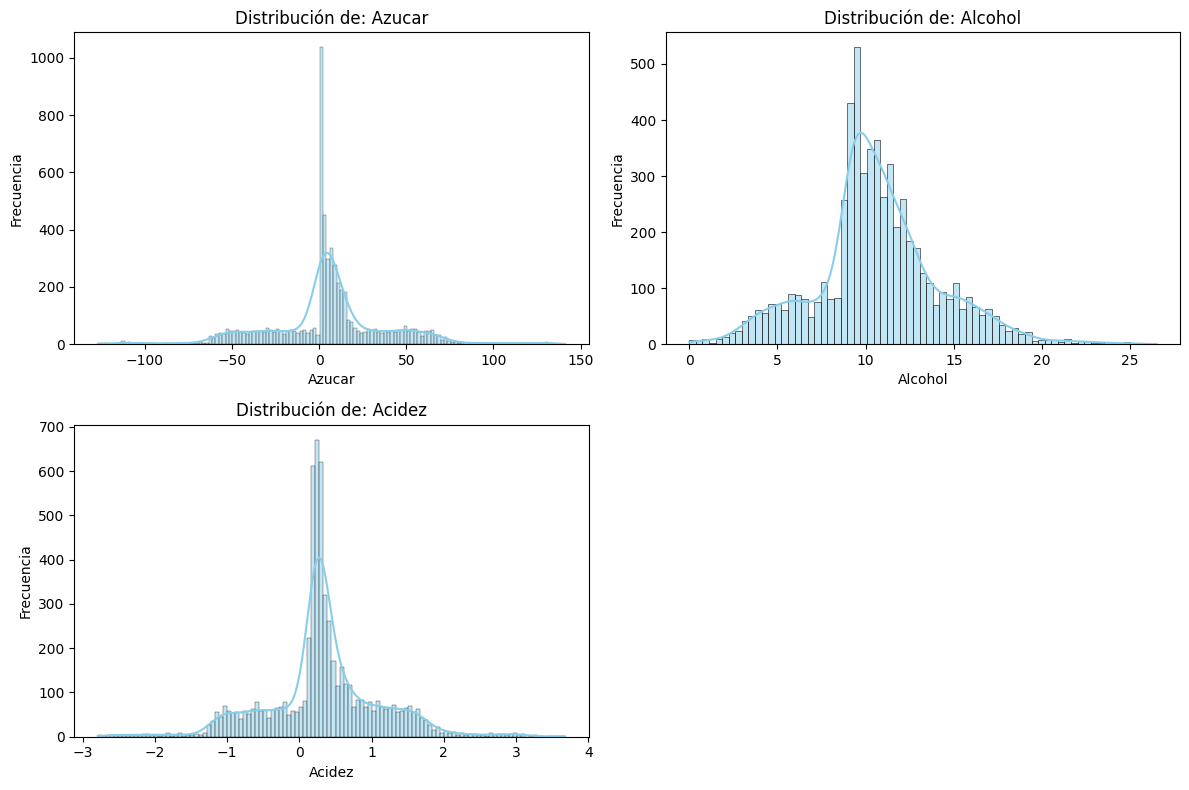

In [47]:
# Visualización de Datos, para ver distribuciones y posibles outliers
variables_a_graficar = ['Azucar', 'Alcohol', 'Acidez'] 

# Calcular el número de subplots necesarios
num_vars = len(variables_a_graficar)

# Determinar el layout de la cuadrícula
# Usamos int(np.ceil(num_vars / 2)) para calcular el número de filas (ej: 4 vars -> 2 filas, 5 vars -> 3 filas)
num_filas = int(np.ceil(num_vars / 2))
num_columnas = 2 

# 3. Crear la Figura y los Subgráficos
fig, axes = plt.subplots(
    nrows=num_filas, 
    ncols=num_columnas, 
    figsize=(12, num_filas * 4) # Ajustar el tamaño de la figura (12 de ancho, 4 por fila)
)

# Aplanar el array de ejes si hay más de 1x1 para facilitar la indexación
axes = axes.flatten()

# 4. Iterar y Graficar
for i, var in enumerate(variables_a_graficar):
    # Usar Seaborn para un histograma con curva de densidad (KDE)
    sns.histplot(
        data=data_full, 
        x=var, 
        kde=True, 
        ax=axes[i], 
        color='skyblue', 
        edgecolor='black'
    )
    axes[i].set_title(f'Distribución de: {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frecuencia')

# 5. Ocultar los ejes vacíos si el número de variables es impar
for j in range(num_vars, num_filas * num_columnas):
    fig.delaxes(axes[j])

# Ajustar el layout para evitar la superposición de títulos
plt.tight_layout()
plt.show()

#### Analisis variables categoricas

In [48]:
data_full.describe()

,Acidez,AcidoCitrico,Azucar,CloruroSodico,Densidad,pH,Sulfatos,Alcohol,CalifProductor,PrecioBotella
count,6365.000000,6365.000000,6065.000000,6066.000000,6365.000000,6170.000000,5761.000000,5977.000000,6365.000000,6365.000000
mean,0.331214,0.314350,5.710330,0.051348,0.994204,3.202207,0.526659,10.630534,2.761508,2.610652
std,0.787534,0.861428,34.497308,0.322715,0.026417,0.678330,0.948039,3.525277,1.319127,1.480274
min,-2.790000,-3.240000,-127.100000,-1.171000,0.888090,0.540000,-3.120000,0.000000,0.000000,1.000000
25%,0.130000,0.020000,-1.700000,-0.032750,0.988245,2.960000,0.280000,9.000000,2.000000,1.420000
50%,0.280000,0.310000,4.100000,0.046000,0.994400,3.190000,0.500000,10.400000,3.000000,2.190000
75%,0.650000,0.580000,16.000000,0.146750,1.000600,3.460000,0.880000,12.400000,3.000000,3.440000
max,3.680000,3.860000,141.150000,1.351000,1.099240,6.050000,4.210000,26.500000,12.000000,11.440000


In [49]:
# Al parecer la variable etiqueta esta asignando valores diferentes a variables iguales (mayusculas y minusculas)
print(data_full["Etiqueta"].value_counts())
data_full["Etiqueta"] = data_full["Etiqueta"].str.upper().astype("category")

# Frecuencias de las categorías de clasificación
print(data_full.Clasificacion.value_counts())

# Tabla de contingencia con la variable objetivo binaria Compra
pd.crosstab(index=data['Compra'], columns=data['Clasificacion'])

# Reemplazar los ? por Deconocido pues representa una categoría importante en volumen y con un posible patrón interesante
data_full["Clasificacion"] = data_full.Clasificacion.replace('?','Desc')
data_full.Clasificacion.value_counts()


Etiqueta
R     2380
M     1357
B     1282
r      420
m      230
MM     216
b      209
MB     191
mb      40
mm      40
Name: count, dtype: int64
Clasificacion
**      1754
?       1680
*       1535
***     1074
****     322
Name: count, dtype: int64


C:\Users\germa\AppData\Local\Temp\ipykernel_11692\701758599.py:12: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  data_full["Clasificacion"] = data_full.Clasificacion.replace('?','Desc')


Clasificacion
**      1754
Desc    1680
*       1535
***     1074
****     322
Name: count, dtype: int64

In [50]:
## agregamos columnas que puedan representar relaciones interesantes
data_full["ratio_densidad_alcohol"]= data_full.Densidad*data_full.Alcohol
data_full["data_precios_rango"] = pd.qcut(data['PrecioBotella'], q=4, labels=['Economico', 'Medio', 'Premium', 'Lujo'])
## tranformamos con logaritmo para compactar los datos y mejorar la distribucion
data_trans_log = data_full.copy()
cols_num = data_trans_log.select_dtypes(include="number").columns
data_trans_log[cols_num] = np.log1p(data_trans_log[cols_num])

# Valoramos distribución
#Proporción de missings por observación (como una nueva columna del dataset)
data_trans_log['prop_missings'] = data_trans_log.apply(lambda x: x.isna().sum(),axis=1)
data_missings = data_trans_log.copy()
data_missings.sort_values(by='prop_missings', ascending=False).head()
data_missings

C:\Users\germa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: divide by zero encountered in log1p
  result = func(self.values, **kwargs)
C:\Users\germa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


,Acidez,AcidoCitrico,Azucar,CloruroSodico,Densidad,pH,Sulfatos,Alcohol,Etiqueta,CalifProductor,Clasificacion,Region,PrecioBotella,ratio_densidad_alcohol,data_precios_rango,prop_missings
0,0.148420,-1.660731,3.299534,-0.553385,0.707011,1.477049,0.530628,NaN,M,1.098612,***,1.0,0.693147,NaN,Economico,2
1,1.291984,-2.120264,2.760010,0.036332,0.690734,1.415853,0.392042,3.135494,M,1.386294,***,3.0,1.477049,3.130873,Premium,0
2,0.254642,-0.510826,3.113515,0.058269,0.691005,1.501853,0.792993,2.424803,R,1.386294,Desc,1.0,1.551809,2.420894,Lujo,0
3,NaN,0.292670,0.875469,0.039221,0.709198,1.435085,NaN,2.533697,B,1.098612,***,2.0,1.978239,2.563053,Lujo,2
4,0.239017,0.717840,2.505526,-0.007025,0.691245,1.780024,0.231112,2.772589,R,0.693147,Desc,2.0,1.235471,2.769020,Premium,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6360,0.329304,0.157004,1.193922,0.094401,0.694262,1.663926,0.113329,2.379546,R,1.609438,*,1.0,0.824175,2.381568,Economico,0
6361,0.524729,0.086178,4.005513,0.043059,0.690544,1.515127,NaN,NaN,MB,1.098612,***,3.0,1.646734,NaN,Lujo,3
6362,0.285179,-2.813411,NaN,0.035367,0.679489,1.383791,NaN,2.708050,R,1.609438,**,1.0,1.033184,2.682403,Medio,2
6363,0.157004,NaN,3.637586,0.075107,0.688516,1.446919,NaN,2.587764,R,0.693147,**,2.0,0.693147,2.579182,Economico,2


## valores atipicos - outliers
Para facilitarnos la vida y complementar la idea que tenemos ya sobre las distribuciones de las variables, llevamos a cabo un conteo de los valores que se consideran extremos según un consenso de dos criterios distintos. En primer lugar, se distingue variable simétrica o posiblemente no, para aplicar *media + 3 sd* ó *mediana + 8 mad*, respectivamente. Recordamos en este punto que todas las medidas de dispersión basadas en la mediana o cuartiles son muy poco sensibles a la presencia de asimetría en la distribución, siendo por ello más fiables en este caso. Por otro lado, aplicamos el clásico criterio del boxplot umbrales en *cuartil1 - 3IQR* y *cuartil3+ 3IQR*. 

Para aclarar, veamos un momento las asimetrías de las variables numéricas.

In [51]:
## calculo de asimetria
data_missings.select_dtypes(include=np.number).apply(lambda x: x.skew())

C:\Users\germa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\nanops.py:1256: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean


Acidez                         NaN
AcidoCitrico                   NaN
Azucar                         NaN
CloruroSodico                  NaN
Densidad                 -0.089214
pH                       -1.050976
Sulfatos                       NaN
Alcohol                  -1.487628
CalifProductor            0.052575
PrecioBotella             0.445543
ratio_densidad_alcohol   -1.476063
prop_missings             1.136457
dtype: float64

Vamos a crear una **función gestiona_outliers** para facilitar el trabajo en este sentido. La idea es tener una sola función que implemente:

1- **Visualización de la incidencia** de outliers --> Toma de decisiones

2- **Gestión** de los mismos: 

  2.1- **Winsorizar**: Colapsar todo valor mayor o menor que los umbrales de cierto rango (dado por percentiles habitualmente) para igualarlo con esos umbrales. Como ya comentábamos, este método conserva la integridad del datos en el sentido de que si era muy grande por la derecha ahora estará en el extremo, pero puede provocar carga excesiva de las colas de la distribución, generando quizá algunas rarezas en picos de densidad.. 
  
  2.2- **Convertir en NAs**: Asumiendo que los valores extremos son inaceptables (es decir, se sospecha que no puede ser tan alto o bajo por alguna razón). Podríamos pensar en que sea un fallo y por tanto decidir pasar a missing esos valores para luego gestionarlos con los valores perdidos. Esta técnica podría incurrir en errores graves de cambio del sentido de la información. Por ejemplo, en este caso un vino muy caro, pero que es un vino real y ese es su precio, es lo que hay...bueno considerando que es erróneo, pasamos a Na e imputamos por media o valor aleatorio, quedando este valor de precio en un entorno central...tal vez hay características que generaban un patrón de precio alto que ahora serán mal aprendidas por el modelo.
  

In [52]:
## Función para winsorizar
from scipy.stats import mstats
from scipy import stats

## Función para gestionar outliers
def gestiona_outliers(col,clas = 'check'):
    print(col.name)
    # Condición de asimetría y aplicación de criterio 1 según el caso
    if abs(col.skew()) < 1:
        criterio1 = abs((col-col.mean())/col.std())>3
    else:
        criterio1 = abs((col-col.median())/stats.median_abs_deviation(col))>6 ## Cambio mad por median_abs_deviation!! 
    
    # Calcular primer cuartil     
    q1 = col.quantile(0.25)  
    # Calcular tercer cuartil  
    q3 = col.quantile(0.75)
    # Calculo de IQR
    IQR=q3-q1
    # Calcular criterio 2 (general para cualquier asimetría)
    criterio2 = (col<(q1 - 3*IQR))|(col>(q3 + 3*IQR))
    lower = col[criterio1&criterio2&(col<q1)].count()/col.dropna().count()
    upper = col[criterio1&criterio2&(col>q3)].count()/col.dropna().count()
    # Salida según el tipo deseado
    if clas == 'check':
        return(lower*100,upper*100,(lower+upper)*100)
    elif clas == 'winsor':
        #  winsorize_with_pandas(col,(lower,upper)
        return(mstats.winsorize(col, limits=[0.05, 0.05]))
    elif clas == 'miss':
        print('\n MissingAntes: ' + str(col.isna().sum()))
        col.loc[criterio1&criterio2] = np.nan
        print('MissingDespues: ' + str(col.isna().sum()) +'\n')
        return(col)
    
# Llamada en modo check diagnostico
data_full.select_dtypes(include=np.number).copy().apply(lambda x: gestiona_outliers(x))#.set_index(['Low','up','Tot'])

Acidez
AcidoCitrico
Azucar
CloruroSodico
Densidad
pH
Sulfatos
Alcohol
CalifProductor
PrecioBotella
ratio_densidad_alcohol


,Acidez,AcidoCitrico,Azucar,CloruroSodico,Densidad,pH,Sulfatos,Alcohol,CalifProductor,PrecioBotella,ratio_densidad_alcohol
0,0.816968,0.848390,0.956307,0.807781,0.942655,0.794165,1.024128,0.000000,0.000000,0.000000,0.000000
1,0.879811,0.785546,0.972795,0.873722,0.942655,0.696921,0.815831,0.317885,0.157109,0.078555,0.368078
2,1.696779,1.633936,1.929101,1.681503,1.885310,1.491086,1.839958,0.317885,0.157109,0.078555,0.368078


In [53]:
# Aplicar la gestión de outliers en modelo winsor
data_winsor = data_missings.copy()
cols_num = data_winsor.select_dtypes(include=np.number).columns
data_winsor[cols_num] = data_winsor[cols_num].apply(lambda x: gestiona_outliers(x, clas='winsor')).clip(lower=0)
data_winsor
# data_winsor = data_winsor.join(data_categorico)
# data_winsor_total = data_winsor.join([varObjBin,varObjCont])
# data_winsor_total

Acidez
AcidoCitrico
Azucar
CloruroSodico
Densidad
pH
Sulfatos
Alcohol
CalifProductor
PrecioBotella
ratio_densidad_alcohol
prop_missings


C:\Users\germa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\nanops.py:1256: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean
C:\Users\germa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\nanops.py:1256: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean
C:\Users\germa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\nanops.py:1256: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean
C:\Users\germa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\nanops.py:1256: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean
C:\Users

,Acidez,AcidoCitrico,Azucar,CloruroSodico,Densidad,pH,Sulfatos,Alcohol,Etiqueta,CalifProductor,Clasificacion,Region,PrecioBotella,ratio_densidad_alcohol,data_precios_rango,prop_missings
0,0.148420,0.000000,3.299534,0.000000,0.707011,1.477049,0.530628,NaN,M,1.098612,***,1.0,0.693147,NaN,Economico,2
1,1.291984,0.000000,2.760010,0.036332,0.690734,1.415853,0.392042,3.135494,M,1.386294,***,3.0,1.477049,3.130873,Premium,0
2,0.254642,0.000000,3.113515,0.058269,0.691005,1.501853,0.792993,2.424803,R,1.386294,Desc,1.0,1.551809,2.420894,Lujo,0
3,NaN,0.292670,0.875469,0.039221,0.709198,1.435085,NaN,2.533697,B,1.098612,***,2.0,1.902108,2.563053,Lujo,2
4,0.239017,0.717840,2.505526,0.000000,0.691245,1.728109,0.231112,2.772589,R,0.693147,Desc,2.0,1.235471,2.769020,Premium,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6360,0.329304,0.157004,1.193922,0.094401,0.694262,1.663926,0.113329,2.379546,R,1.609438,*,1.0,0.824175,2.381568,Economico,0
6361,0.524729,0.086178,4.005513,0.043059,0.690544,1.515127,NaN,NaN,MB,1.098612,***,3.0,1.646734,NaN,Lujo,2
6362,0.285179,0.000000,NaN,0.035367,0.679489,1.383791,NaN,2.708050,R,1.609438,**,1.0,1.033184,2.682403,Medio,2
6363,0.157004,NaN,3.637586,0.075107,0.688516,1.446919,NaN,2.587764,R,0.693147,**,2.0,0.693147,2.579182,Economico,2


### Missings

<Axes: >

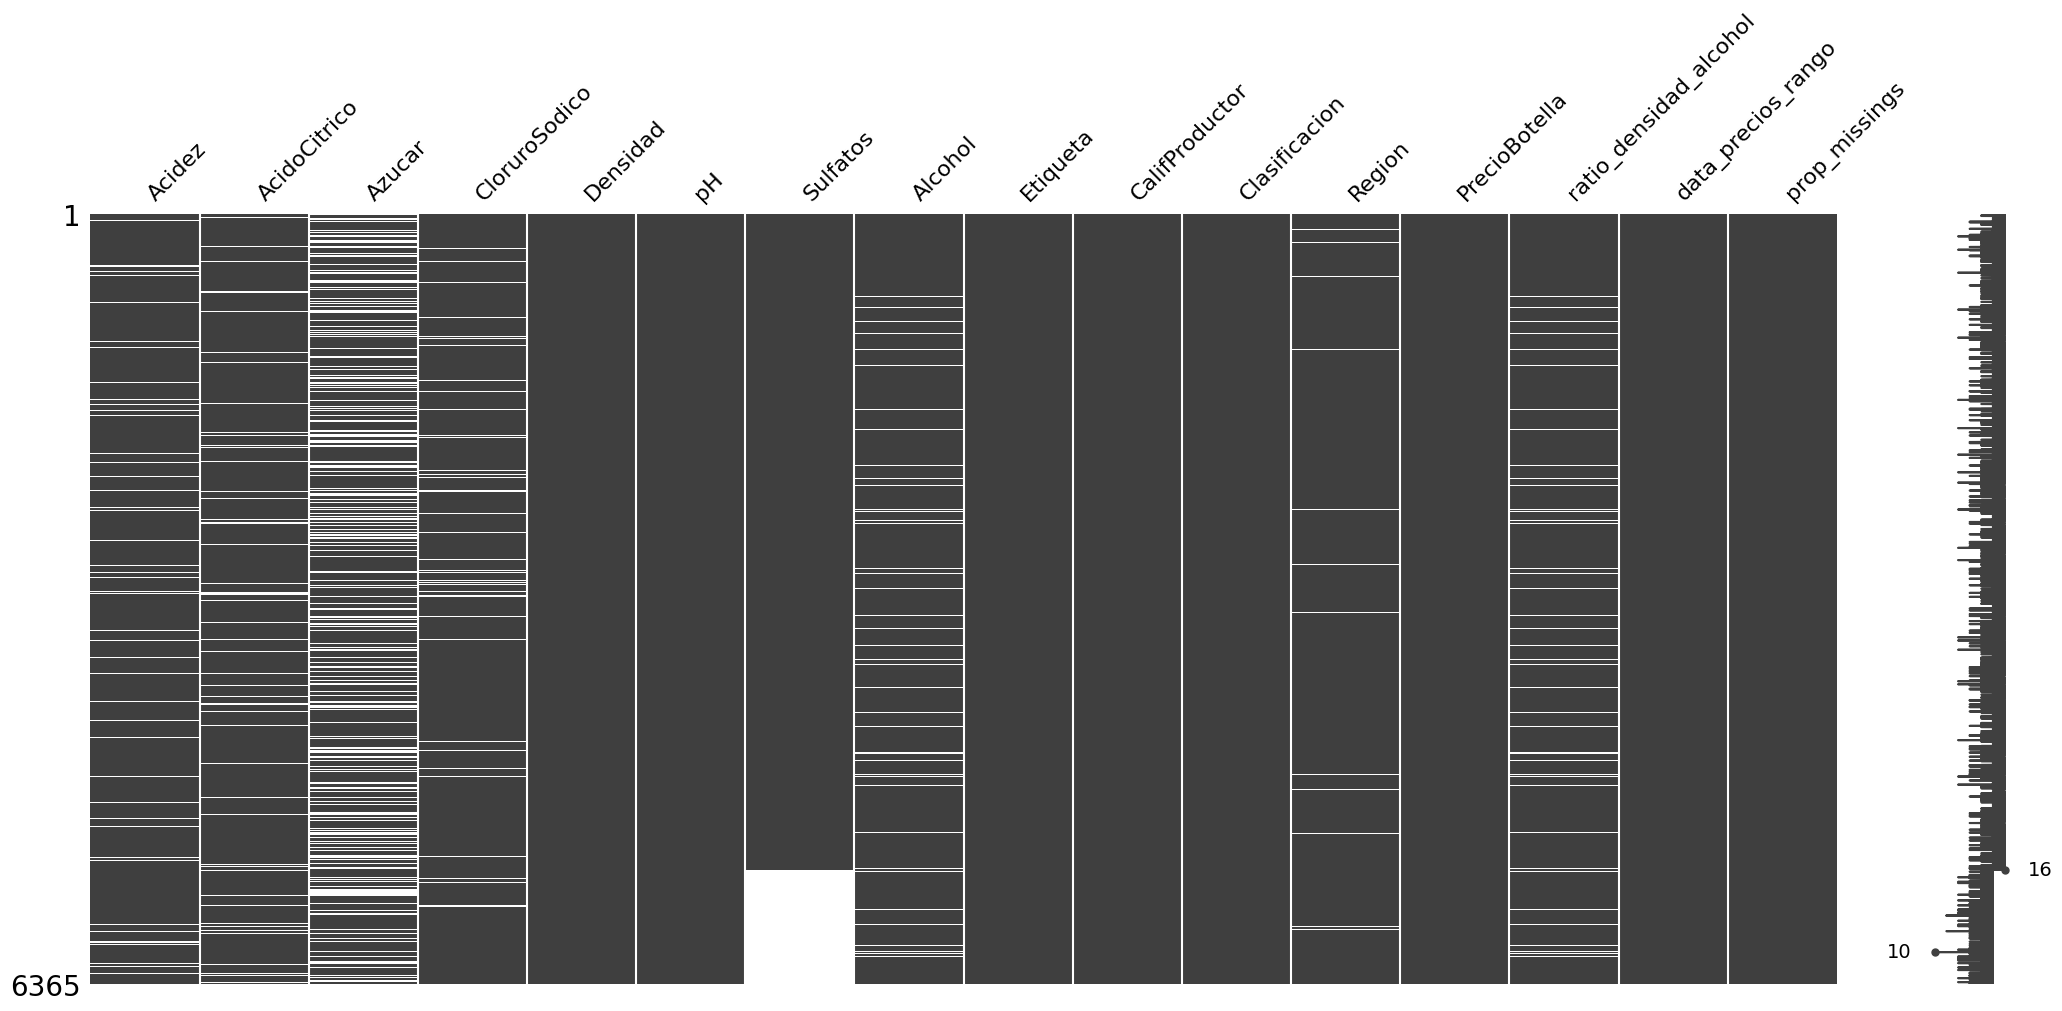

In [54]:
## vemos visualmente como se ve el dataset con los valores null
#conda config --add channels conda-forge
#conda install missingno
# pip install missingno
import missingno as msno   
# Plot correlation heatmap of missingness
msno.matrix(data_winsor.sort_values(by='Sulfatos'))

In [63]:
from sklearn.pipeline import Pipeline 
X_train, X_test, y_train, y_test = train_test_split(
    data_winsor, varObjBin, test_size=0.2, random_state=42, stratify=varObjBin  # stratify respeta el desbalance
)
data_numerico = X_train.select_dtypes(include="number").copy()
data_categorico = X_train.select_dtypes(include="category").copy()
y_train


2269    0
653     1
4241    1
2656    0
3014    1
       ..
2417    1
4938    1
6163    1
3298    0
5791    0
Name: Compra, Length: 5092, dtype: category
Categories (2, int64): [0, 1]

### Tratamiento de missings

In [56]:
# estandarizamos para que funcione mejor el knn
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data_scaled = scaler.fit_transform(X_train.select_dtypes(include="number"))
data_standarizado = pd.DataFrame(data_scaled, columns=X_train.select_dtypes(include="number").columns)
data_standarizado.head() 

,Acidez,AcidoCitrico,Azucar,CloruroSodico,Densidad,pH,Sulfatos,Alcohol,CalifProductor,PrecioBotella,ratio_densidad_alcohol,prop_missings
0,-1.138039,NaN,0.008730,-0.712662,-0.002466,1.922136,1.200436,NaN,1.187614,-1.084861,NaN,1.696124
1,-1.138039,-0.393830,-1.309181,-0.457025,0.165351,-0.984776,-0.502843,-0.474937,-0.565289,-1.048676,-0.459981,-0.976111
2,0.753386,3.129190,-0.111485,1.229800,0.056748,0.040249,-0.420659,NaN,-0.565289,-0.537063,NaN,1.696124
3,2.057103,0.112898,0.286814,2.939563,0.366310,-0.069587,NaN,-0.543810,1.813252,-0.908583,-0.515097,0.360007
4,-0.535964,-0.299424,-1.140547,-0.120450,0.261481,0.224377,-1.374606,0.666466,-1.956646,0.033241,0.682590,-0.976111


In [64]:
# knn imputer para numericas y moda para categoricas
from sklearn.impute import KNNImputer
import sklearn.impute as skl_imp

imputer_moda = skl_imp.SimpleImputer(strategy='most_frequent', missing_values=np.nan)
imputer = KNNImputer(n_neighbors=4)
data_knn_num = imputer.fit_transform(data_standarizado)


data_imputed = pd.DataFrame(data_knn_num, columns=data_standarizado.columns)
data_knn_cat = pd.DataFrame(imputer_moda.fit_transform(X_train.select_dtypes(exclude="number")),columns=data_categorico.columns)

data_imputed=data_imputed.join(data_knn_cat)
data_imputed.isnull().sum() 


Acidez                    0
AcidoCitrico              0
Azucar                    0
CloruroSodico             0
Densidad                  0
pH                        0
Sulfatos                  0
Alcohol                   0
CalifProductor            0
PrecioBotella             0
ratio_densidad_alcohol    0
prop_missings             0
Etiqueta                  0
Clasificacion             0
Region                    0
data_precios_rango        0
dtype: int64

In [65]:
# data_imputed_Total = data_imputed.join(varObjBin)
# data_imputed_Total
data_dummies = pd.get_dummies(X_train,drop_first=True)
data_dummies


,Acidez,AcidoCitrico,Azucar,CloruroSodico,Densidad,pH,Sulfatos,Alcohol,CalifProductor,PrecioBotella,...,Etiqueta_R,Clasificacion_**,Clasificacion_***,Clasificacion_****,Clasificacion_Desc,Region_2.0,Region_3.0,data_precios_rango_Medio,data_precios_rango_Premium,data_precios_rango_Lujo
2269,0.000000,NaN,2.370244,0.000000,0.690173,1.728109,0.908259,NaN,1.609438,0.802002,...,False,False,False,False,False,True,False,False,False,False
653,0.000000,0.239017,0.832909,0.041142,0.692077,1.286474,0.307485,2.272126,1.098612,0.815365,...,False,False,False,False,True,True,False,False,False,False
4241,0.598837,1.396245,2.230014,0.312619,0.690845,1.442202,0.336472,NaN,1.098612,1.004302,...,True,False,True,False,False,False,True,True,False,False
2656,1.011601,0.405465,2.694627,0.587787,0.694356,1.425515,NaN,2.251292,1.791759,0.867100,...,True,False,False,False,True,False,True,False,False,False
3014,0.190620,0.270027,1.029619,0.095310,0.693167,1.470176,0.000000,2.617396,0.693147,1.214913,...,False,False,True,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2417,1.351962,0.000000,1.252763,0.084341,0.686792,1.631199,0.488580,2.785011,1.386294,0.867100,...,False,False,False,False,True,False,True,False,False,False
4938,0.756122,0.165514,4.238445,0.031499,0.688707,1.430311,0.751416,NaN,0.693147,0.693147,...,True,False,False,False,False,False,False,False,False,False
6163,0.533565,0.797507,4.110874,0.084341,0.676093,1.463255,1.075002,2.341806,1.791759,0.693147,...,False,True,False,False,False,False,True,False,False,False
3298,NaN,0.277632,3.713572,0.051643,0.688436,1.418277,0.246860,2.493205,1.386294,0.727549,...,False,False,False,False,True,False,False,False,False,False


### Features engineering


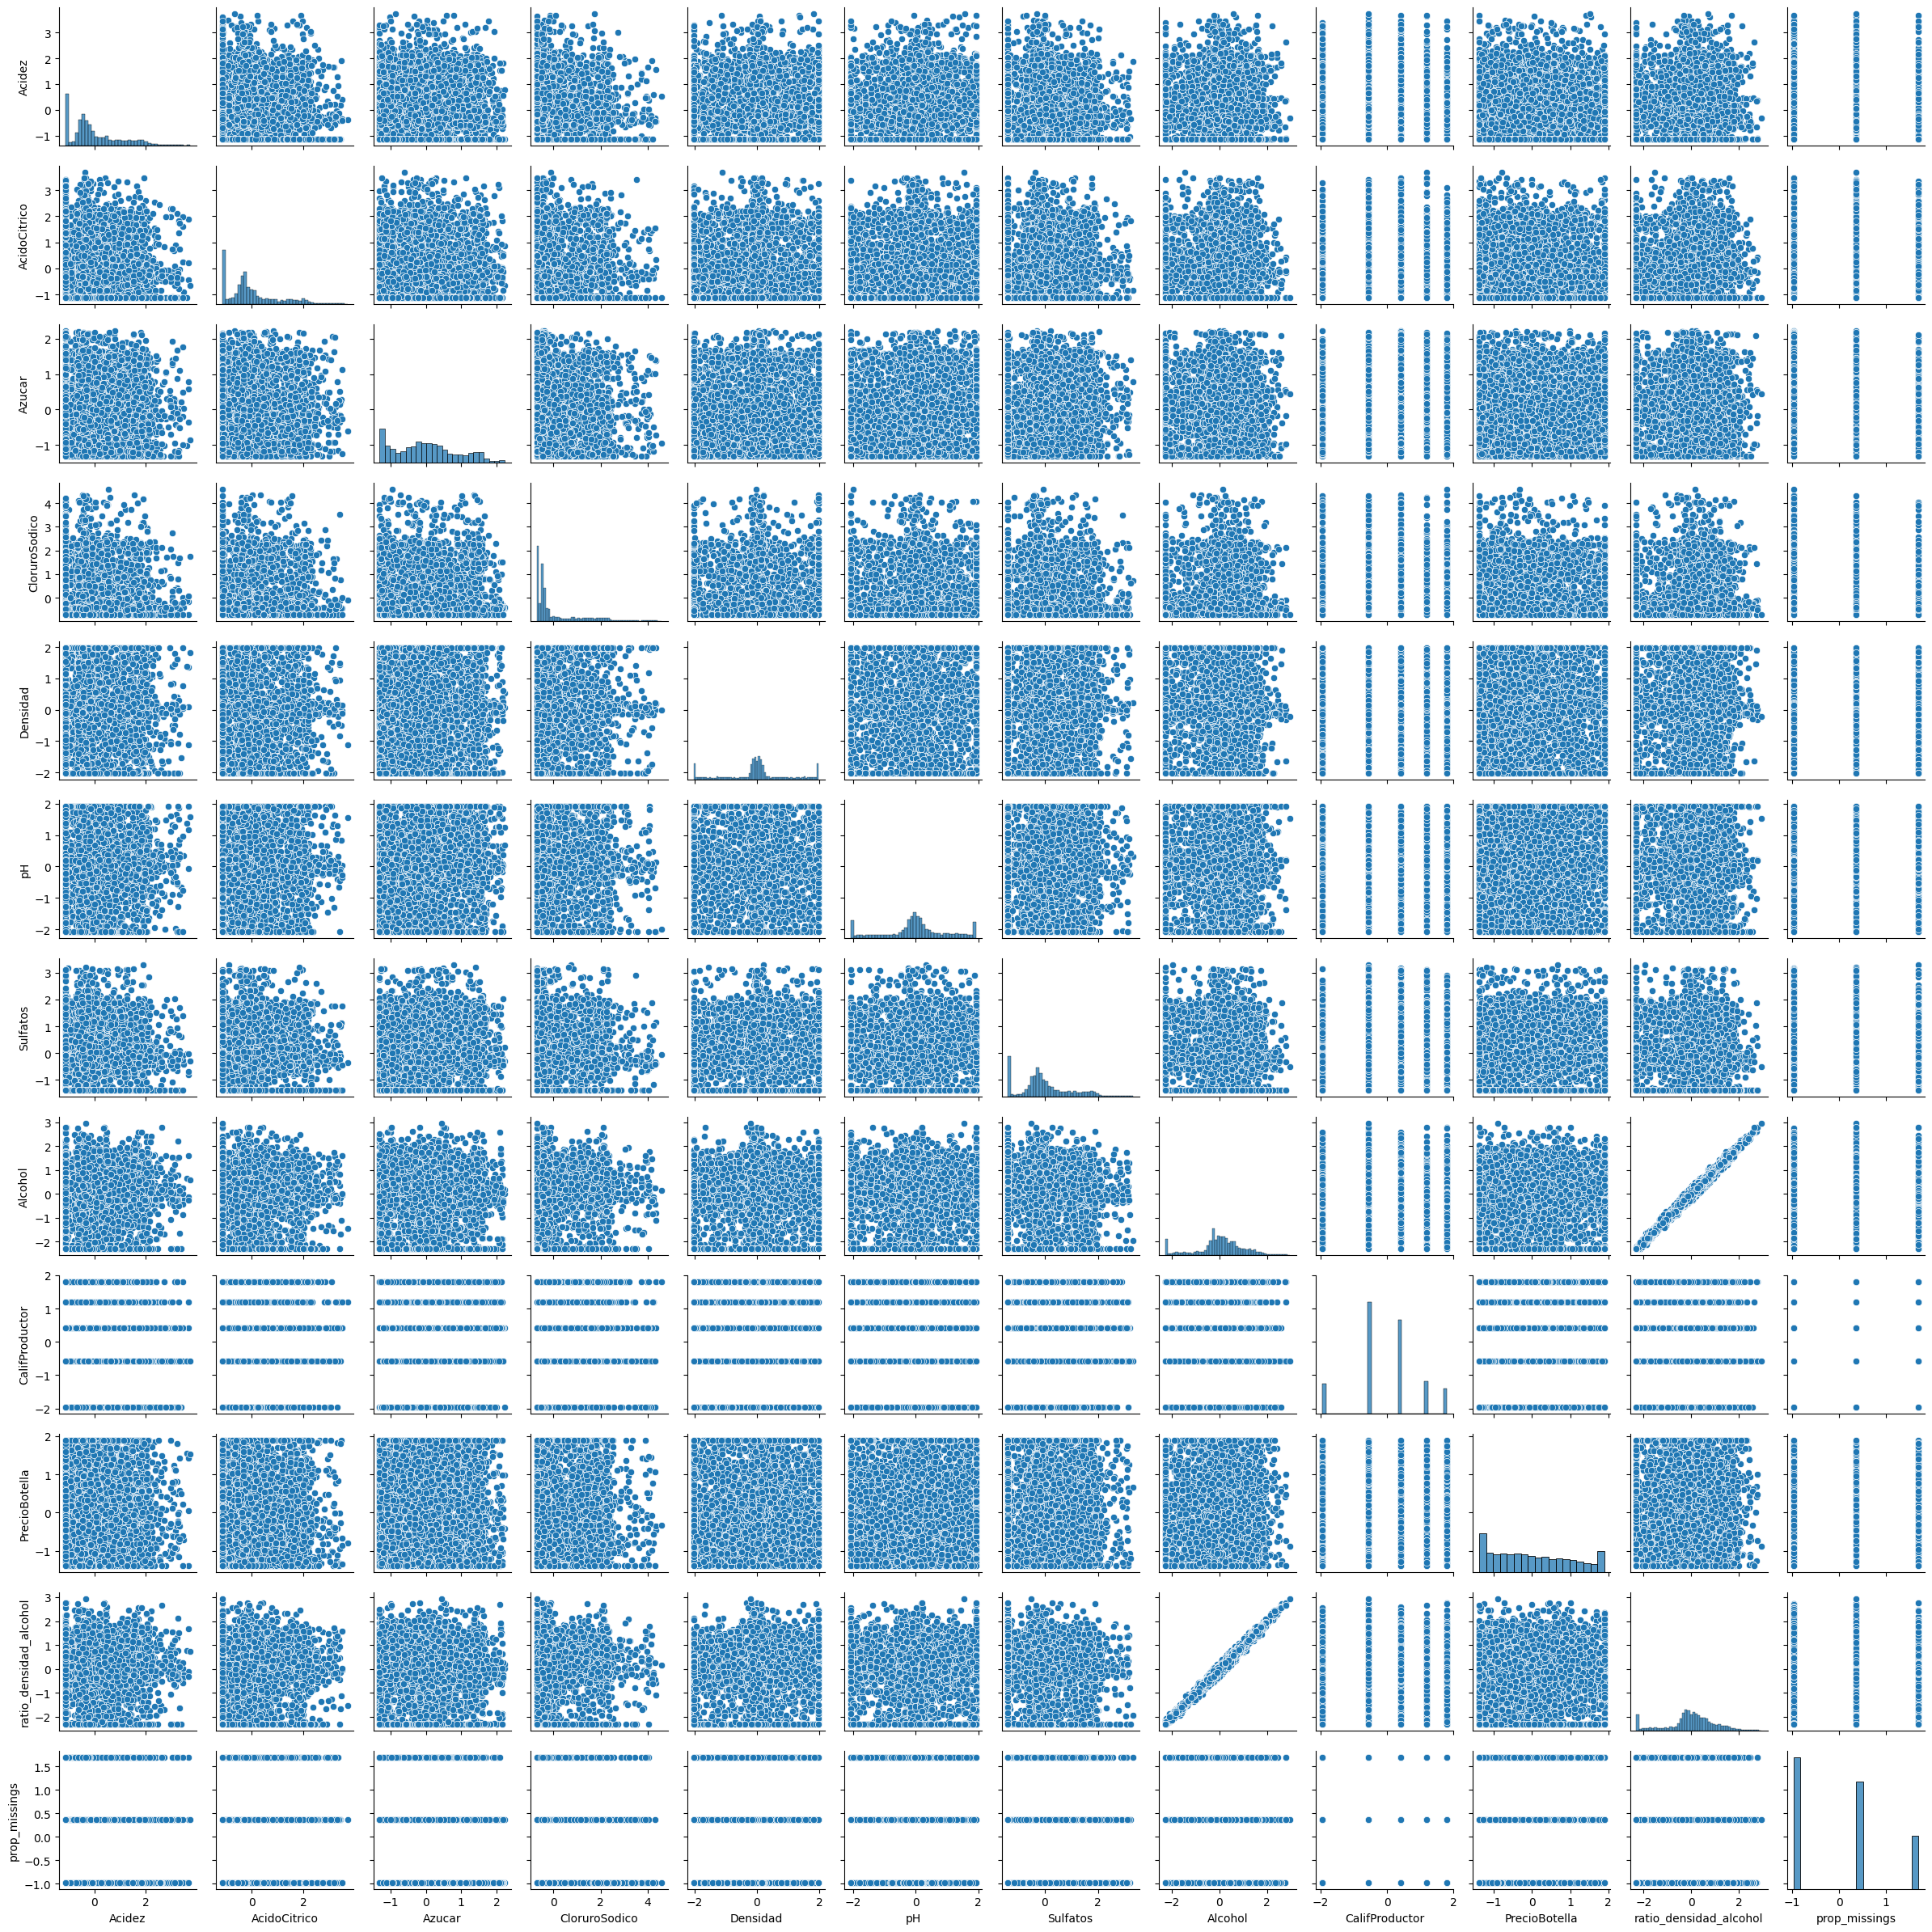

In [59]:
sns.pairplot(data_imputed.select_dtypes(include='number'), height=2)
plt.tight_layout()
plt.show()

In [66]:
from sklearn.tree import DecisionTreeClassifier
from mlxtend.feature_selection import SequentialFeatureSelector as sfs
## usamos arboles
clf = DecisionTreeClassifier(max_depth=5) 

# 2. Definimos el selector
sfs_back = sfs(clf, 
            k_features='best', 
            forward=False,   # Backward
            floating=False, 
            scoring='accuracy', # Usamos Accuracy para clasificación
            cv=5, 
            n_jobs=1)

sfs_back = sfs_back.fit(data_dummies, y_train)

print("Mejores variables:", sfs_back.k_feature_names_)
print("Mejor Score:", sfs_back.k_score_)

Mejores variables: ('Azucar', 'CalifProductor', 'Etiqueta_M', 'Clasificacion_**', 'Clasificacion_***', 'Clasificacion_****', 'Clasificacion_Desc')
Mejor Score: 0.8611534093866826


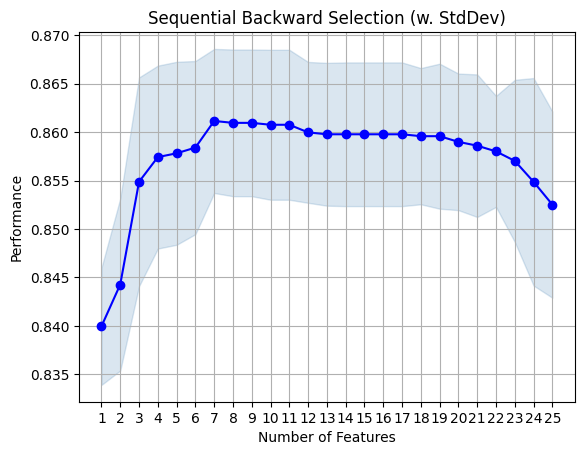

In [67]:
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs
import matplotlib.pyplot as plt

fig1 = plot_sfs(sfs_back.get_metric_dict(), kind='std_dev')

#plt.ylim([0.8, 1])
plt.title('Sequential Backward Selection (w. StdDev)')
plt.grid()
plt.show()


In [69]:
x_final = data_dummies[list(sfs_back.k_feature_names_)]
x_final

,Azucar,CalifProductor,Etiqueta_M,Clasificacion_**,Clasificacion_***,Clasificacion_****,Clasificacion_Desc
2269,2.370244,1.609438,False,False,False,False,False
653,0.832909,1.098612,True,False,False,False,True
4241,2.230014,1.098612,False,False,True,False,False
2656,2.694627,1.791759,False,False,False,False,True
3014,1.029619,0.693147,False,False,True,False,False
...,...,...,...,...,...,...,...
2417,1.252763,1.386294,False,False,False,False,True
4938,4.238445,0.693147,False,False,False,False,False
6163,4.110874,1.791759,False,True,False,False,False
3298,3.713572,1.386294,False,False,False,False,True


In [71]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# X_train, X_test, y_train, y_test = train_test_split(x_final, varObjBin, test_size=0.3, random_state=42)
clf = DecisionTreeClassifier(class_weight='balanced',max_depth=5, random_state=42) # Usamos profundidad para evitar que el árbol crezca infinito
clf.fit(x_final, y_train)

# Evaluación mejorada
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

# Visualizar Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Acidez
- AcidoCitrico
- Alcohol
- Clasificacion
- CloruroSodico
- ...
Feature names seen at fit time, yet now missing:
- Clasificacion_**
- Clasificacion_***
- Clasificacion_****
- Clasificacion_Desc
- Etiqueta_M


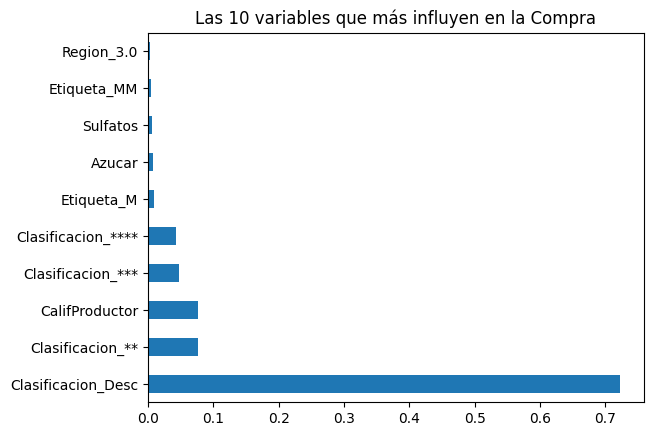

In [ ]:
import matplotlib.pyplot as plt

importances = pd.Series(clf.feature_importances_, index=x_final.columns)
importances.nlargest(10).plot(kind='barh')
plt.title("Las 10 variables que más influyen en la Compra")
plt.show()